# 🏛️ Auction House Data Analysis

This notebook explores two datasets from an auction house:

| File | Contents |
|------|----------|
| `Auctions_and_contacts.xlsx` | **Auction Items** (137 lots), **Contacts** (155 buyers/sellers), **Auction Details** (6 events) |
| `Full_Catalog.xlsx` | **Full Catalog** (137 objects with descriptions and catalog prices) |
| `Financial_transactions.xlsx` | **Financial Transactions** (188 transactions with contact ids) |

Work through the guided sections, then tackle the open-ended challenges at the end.

## 0. Setup

In [1]:
%pip install pandas
%pip install matplotlib
%pip install seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Consistent visual style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 110

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load the Data

In [13]:
# ── Auctions_and_contacts ──────────────────────────────────────────────────
items    = pd.read_excel('Auctions_and_contacts.xlsx', sheet_name='Auction Items')
contacts = pd.read_excel('Auctions_and_contacts.xlsx', sheet_name='Contacts')
auctions = pd.read_excel('Auctions_and_contacts.xlsx', sheet_name='Auction Details')

# ── Full_Catalog ───────────────────────────────────────────────────────────
catalog  = pd.read_excel('Full_Catalog.xlsx', sheet_name='Full Catalog')

# ── Financial Transactions ─────────────────────────────────────────────────
transactions = pd.read_excel('Financial_transactions.xlsx', sheet_name='Financial transactions')


print(f'Auction Items : {items.shape}')
print(f'Contacts      : {contacts.shape}')
print(f'Auction Details: {auctions.shape}')
print(f'Full Catalog  : {catalog.shape}')
print(f'Financial Transactions: {transactions.shape}')

Auction Items : (137, 6)
Contacts      : (155, 4)
Auction Details: (6, 3)
Full Catalog  : (137, 4)
Financial Transactions: (188, 2)


## 2. First Look at Each Table

Before any analysis, always inspect your data. Run each cell and note:
- What are the column names and types?
- Are there any missing values?
- Do the values look sensible?

In [ ]:
print('=== Auction Items ===')
print(items.dtypes)
print()
items.head()

=== Auction Items ===
Auction_id      int64
Object_id      object
Start_Bid       int64
Sold_for        int64
Buyer_ID      float64
Seller_ID       int64
dtype: object



,Auction_id,Object_id,Start_Bid,Sold_for,Buyer_ID,Seller_ID
0,3,B1,23100,0,NaN,11
1,1,B2,10500,14000,153.0,12
2,2,B3,8775,12000,151.0,13
3,3,B4,7725,8000,151.0,14
4,1,B5,5250,7000,149.0,15


In [ ]:
print('=== Contacts ===')
print(contacts.dtypes)
print()
contacts.head()

=== Contacts ===
Contact _ID     int64
First_Name     object
Last_name      object
Country        object
dtype: object



,Contact _ID,First_Name,Last_name,Country
0,1,Florence,Abrams,US
1,2,Daffodil,Albero,GB
2,3,Amanda,Winship,AU
3,4,Bernardino,Midgley,FR
4,5,Art,Porcher,JP


In [ ]:
print('=== Auction Details ===')
auctions

=== Auction Details ===


,Auction,Date,Auction_name
0,1,2015-04-14,Spring Antiqueties
1,2,2015-06-19,Special Summer Event
2,3,2016-10-24,Fall Ball
3,4,2016-04-03,Winter Festival
4,5,2016-06-01,No name yet
5,6,2016-09-01,No name yet


In [ ]:
print('=== Full Catalog ===')
print(catalog.dtypes)
print()
catalog.head()

=== Full Catalog ===
ObjectDescription    object
Object_id            object
CatalogPrice          int64
dtype: object



,ObjectDescription,Object_id,CatalogPrice
0,"Alexander Hamilton, John Jay, James Madison - ...",B19,1300
1,Alfred Stieglitz - Georgia O'Keeffe (Hands) (...,F10,147000
2,Alfred Stieglitz - Georgia O'Keeffe Nude (1919),F11,136000
3,"Amedeo Modigliani - Nude Sitting on a Divan (""...",P37,36
4,Andreas Gursky - 99 Cent II Diptychon (2001),F4,334645


In [14]:
print('=== Financial Transactions ===')
print(transactions.dtypes)
print()
transactions.head()

=== Financial Transactions ===
Contact_ID_KEY      int64
Amount            float64
dtype: object



,Contact_ID_KEY,Amount
0,12,-13990.0
1,13,-11985.0
2,14,-7990.0
3,15,-6990.0
4,16,-6000.0


## 3. Data Check

In [15]:
# Missing values in each table
for name, df in [('Auction Items', items), ('Contacts', contacts),
                 ('Auction Details', auctions), ('Catalog', catalog),
                 ('Financial Transactions', transactions)]:
    missing = df.isnull().sum()
    if missing.any():
        print(f'\n{name} — missing values:')
        print(missing[missing > 0])
    else:
        print(f'{name} — no missing values ✓')


Auction Items — missing values:
Buyer_ID    43
dtype: int64
Contacts — no missing values ✓
Auction Details — no missing values ✓
Catalog — no missing values ✓
Financial Transactions — no missing values ✓


In [16]:
# Lots where Sold_for == 0 are unsold
unsold = items[items['Sold_for'] == 0]
sold   = items[items['Sold_for'] > 0]

print(f'Total lots  : {len(items)}')
print(f'Sold        : {len(sold)}  ({len(sold)/len(items)*100:.1f}%)')
print(f'Unsold      : {len(unsold)}  ({len(unsold)/len(items)*100:.1f}%)')

Total lots  : 137
Sold        : 94  (68.6%)
Unsold      : 43  (31.4%)


## 4. Joining the Tables

The real power comes from combining tables.  
`Object_id` links **Auction Items** ↔ **Full Catalog**.  
`Auction_id` links **Auction Items** ↔ **Auction Details**.

In [ ]:
# Join items with catalog to get descriptions and catalog prices
merged = items.merge(catalog, on='Object_id', how='left')

# Join with auction details
merged = merged.merge(
    auctions.rename(columns={'Auction': 'Auction_id'}),
    on='Auction_id',
    how='left'
)

print(f'Merged table shape: {merged.shape}')
merged.head(3)

Merged table shape: (137, 10)


,Auction_id,Object_id,Start_Bid,Sold_for,Buyer_ID,Seller_ID,ObjectDescription,CatalogPrice,Date,Auction_name
0,3,B1,23100,0,NaN,11,Leonardo da Vinci - Codex Leicester,30800,2016-10-24,Fall Ball
1,1,B2,10500,14000,153.0,12,Unknown - St Cuthbert Gospel,14000,2015-04-14,Spring Antiqueties
2,2,B3,8775,12000,151.0,13,Order of Saint Benedict - Gospels of Henry the...,11700,2015-06-19,Special Summer Event


In [ ]:
# Add a column: did the item beat its catalog price?
sold_only = merged[merged['Sold_for'] > 0].copy()
sold_only['above_catalog'] = sold_only['Sold_for'] > sold_only['CatalogPrice']
sold_only['hammer_vs_catalog_pct'] = (
    (sold_only['Sold_for'] - sold_only['CatalogPrice']) / sold_only['CatalogPrice'] * 100
).round(1)

print(f"Items that sold above catalog price: {sold_only['above_catalog'].sum()} "
      f"({sold_only['above_catalog'].mean()*100:.1f}%)")
sold_only[['Object_id', 'ObjectDescription', 'CatalogPrice', 'Sold_for',
           'hammer_vs_catalog_pct']].head(8)

Items that sold above catalog price: 53 (56.4%)


,Object_id,ObjectDescription,CatalogPrice,Sold_for,hammer_vs_catalog_pct
1,B2,Unknown - St Cuthbert Gospel,14000,14000,0.0
2,B3,Order of Saint Benedict - Gospels of Henry the...,11700,12000,2.6
3,B4,John James Audubon - The Birds of America,10300,8000,-22.3
4,B5,Geoffrey Chaucer - The Canterbury Tales,7000,7000,0.0
5,B6,William Shakespeare - First Folio,5600,6000,7.1
6,B7,Pierre-Joseph Redouté - Les Liliacées,5000,4000,-20.0
7,B8,Gutenberg Bible,4900,5000,2.0
8,B9,Claudius Ptolemy - Geographia Cosmographia,3500,3000,-14.3


## 5. Summary Statistics

In [ ]:
print('=== Sold lots — price summary ===')
sold_only[['Start_Bid', 'CatalogPrice', 'Sold_for']].describe().applymap(
    lambda x: f'${x:,.0f}' if pd.notna(x) else x
)

=== Sold lots — price summary ===


/var/folders/t2/lz46j3q93dzc3by2f5s12c4w0000gn/T/ipykernel_71493/1629268278.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  sold_only[['Start_Bid', 'CatalogPrice', 'Sold_for']].describe().applymap(


,Start_Bid,CatalogPrice,Sold_for
count,$94,$94,$94
mean,"$80,225","$91,811","$95,872"
std,"$171,081","$232,875","$182,148"
min,"$1,050",$32,"$1,000"
25%,"$24,938",$54,"$30,250"
50%,"$37,125","$20,930","$45,500"
75%,"$86,361","$114,330","$102,250"
max,"$1,564,643","$2,086,190","$1,629,000"


In [ ]:
# Revenue per auction
revenue = (
    merged[merged['Sold_for'] > 0]
    .groupby('Auction_name')['Sold_for']
    .agg(lots_sold='count', total_revenue='sum', avg_hammer='mean')
    .sort_values('total_revenue', ascending=False)
)
revenue['total_revenue'] = revenue['total_revenue'].map('${:,.0f}'.format)
revenue['avg_hammer']    = revenue['avg_hammer'].map('${:,.0f}'.format)
revenue

,lots_sold,total_revenue,avg_hammer
Auction_name,,,
Special Summer Event,30,"$3,813,000","$127,100"
Spring Antiqueties,36,"$2,665,000","$74,028"
Fall Ball,28,"$2,534,000","$90,500"


## 6. Visualisations

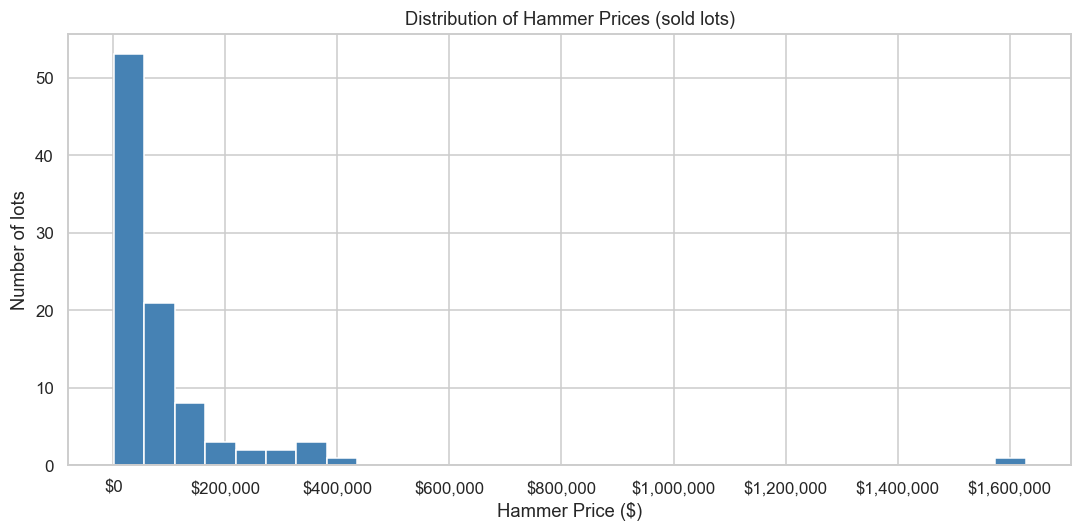


Note: the distribution is heavily right-skewed — a few very high-value lots pull the mean well above the median.


In [ ]:
# ── 6a. Hammer price distribution (sold lots) ─────────────────────────────
fig, ax = plt.subplots()
ax.hist(sold_only['Sold_for'], bins=30, edgecolor='white', color='steelblue')
ax.set_title('Distribution of Hammer Prices (sold lots)')
ax.set_xlabel('Hammer Price ($)')
ax.set_ylabel('Number of lots')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

print('\nNote: the distribution is heavily right-skewed — a few very high-value '
      'lots pull the mean well above the median.')

## 7. Top Performers

In [ ]:
# Top 10 lots by hammer price
top10 = (
    sold_only
    .nlargest(10, 'Sold_for')
    [['ObjectDescription', 'Auction_name', 'CatalogPrice', 'Sold_for', 'hammer_vs_catalog_pct']]
    .reset_index(drop=True)
)
top10.index += 1  # 1-indexed
top10['CatalogPrice'] = top10['CatalogPrice'].map('${:,.0f}'.format)
top10['Sold_for']     = top10['Sold_for'].map('${:,.0f}'.format)
top10['hammer_vs_catalog_pct'] = top10['hammer_vs_catalog_pct'].map('{:+.1f}%'.format)
top10

,ObjectDescription,Auction_name,CatalogPrice,Sold_for,hammer_vs_catalog_pct
1,Domaines Barons de Rothschild Chateau Lafite-R...,Special Summer Event,"$2,086,190","$1,629,000",-21.9%
2,Andreas Gursky - Rhein II (1999),Spring Antiqueties,"$433,850","$394,000",-9.2%
3,Cindy Sherman - Untitled #96 (1981),Special Summer Event,"$389,050","$358,000",-8.0%
4,Jeff Wall - Dead Troops Talk (A vision after ...,Fall Ball,"$366,650","$358,000",-2.4%
5,Andreas Gursky - 99 Cent II Diptychon (2001),Spring Antiqueties,"$334,645","$357,000",+6.7%
6,Domaine de la Romanee-Conti Romanee-Conti Gran...,Spring Antiqueties,"$385,000","$310,000",-19.5%
7,"Petrus, Pomerol, France - 1933",Fall Ball,"$349,630","$277,000",-20.8%
8,Edward Steichen - The Pond-Moonlight (1904),Special Summer Event,"$292,800","$262,000",-10.5%
9,"Chateau Lafleur, Pomerol, France - 1967",Special Summer Event,"$283,910","$226,000",-20.4%
10,Cindy Sherman - Untitled #153 (1985),Fall Ball,"$270,000","$213,000",-21.1%
